# Ejercicio 2

**Consigna:**

a) Elegir algún modelo clásico de clasificación (por ejemplo: random forest o regresión logística). Entrenar y evaluar su performance usando las métricas clásicas (precision, recall, accuracy, f1-score) y crear la matriz de confusión. Interpretar los resultados obtenidos hasta el momento.

b) Suponiendo que su equipo forma parte de la entidad asignada en la Tabla y su objetivo planteado en el enunciado ¿cuál de los errores consideran que es peor en este caso? Justificar.

---
## Nota sobre el enfoque

En el **Ejercicio 1** establecimos que este dataset no cuenta con una variable de género directa. Identificamos dos proxies relevantes:

1. **`job` como proxy de género**: históricamente, trabajos como `housemaid` y `admin.` fueron realizados casi exclusivamente por mujeres.
2. **`marital` como variable protegida oficial**: el estado civil correlaciona con la etapa de vida (solteros tienden a ser más jóvenes, casados de mediana edad, divorciados más mayores).

En este ejercicio construiremos el modelo base y luego analizaremos su performance desglosada por **ambas** variables protegidas.

Además, tal como advertimos en el Ej1, **excluimos la variable `duration`** del modelo ya que representa un caso claro de *data leakage*: la duración de la llamada solo se conoce después de que la llamada ocurrió y correlaciona directamente con el resultado.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, recall_score,
    precision_score, accuracy_score
)
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style='whitegrid', palette='muted')
print('Librerías cargadas.')

Librerías cargadas.


In [2]:
# Carga del dataset
df = pd.read_csv('data/full.csv', sep=';')
print(f'Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas')
df.head()

Dataset cargado: 41188 filas, 21 columnas


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Preprocesamiento

Pasos:
1. **Eliminar `duration`**: data leakage (ver justificación en Ej1, sección iv)
2. **Filtrar `marital == 'unknown'`**: solo 80 registros, no aportan información al análisis de equidad
3. **Codificar** variables categóricas con LabelEncoder
4. **Split** estratificado 80/20 (por el desbalance de clases ~90% 'no')

In [3]:
# 1. Eliminar duration (data leakage)
df = df.drop(columns=['duration'])

# 2. Filtrar marital == 'unknown' (solo 80 de 41188)
df = df[df['marital'] != 'unknown'].reset_index(drop=True)
print(f'Dataset tras filtro: {df.shape[0]} filas')

# Guardar copia original para análisis posterior
df_original = df.copy()

# 3. Codificar categóricas
df_encoded = df.copy()
for col in df_encoded.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

# 4. Separar features y target
X = df_encoded.drop(columns=['y'])
y = df_encoded['y']

# Split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')
print(f'Distribución en test - No: {(y_test == 0).sum()} | Sí: {(y_test == 1).sum()}')
print('Preprocesamiento completado.')

Dataset tras filtro: 41108 filas
Train: 32886 | Test: 8222
Distribución en test - No: 7296 | Sí: 926
Preprocesamiento completado.


## a) Entrenamiento y evaluación del modelo

Elegimos **Random Forest** como modelo base por:
- Robustez ante features mixtas (numéricas + categóricas codificadas)
- Buen rendimiento como baseline sin hiperparámetros complejos
- Popularidad como benchmark en la literatura de fairness

         REPORTE DE CLASIFICACIÓN
              precision    recall  f1-score   support

          no       0.92      0.97      0.94      7296
         yes       0.60      0.30      0.40       926

    accuracy                           0.90      8222
   macro avg       0.76      0.64      0.67      8222
weighted avg       0.88      0.90      0.88      8222



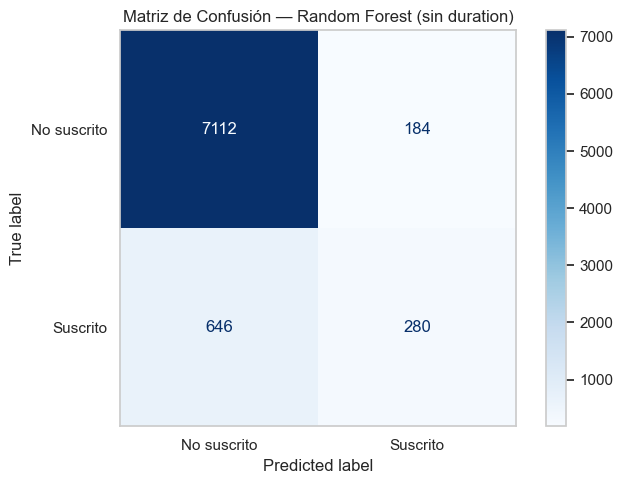

In [4]:
# Entrenamiento
modelo = RandomForestClassifier(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)

# Predicciones
y_pred = modelo.predict(X_test)

# Reporte de clasificación
print('=' * 55)
print('         REPORTE DE CLASIFICACIÓN')
print('=' * 55)
# LabelEncoder ordena alfabéticamente: no=0, yes=1
print(classification_report(y_test, y_pred, target_names=['no', 'yes']))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No suscrito', 'Suscrito']
)
disp.plot(cmap='Blues', ax=ax)
plt.title('Matriz de Confusión — Random Forest (sin duration)')
plt.grid(False)
plt.tight_layout()
plt.show()

### Interpretación (inciso a)

El modelo presenta un **accuracy elevado** (~90%), lo cual a primera vista parece satisfactorio. Sin embargo, al examinar las métricas por clase observamos un patrón común en datasets desbalanceados:

- **Clase 'no' (no suscrito)**: Precision, recall y F1 altos. El modelo es muy bueno identificando a quienes NO se suscribirán.
- **Clase 'yes' (suscrito)**: Recall significativamente más bajo. El modelo tiene dificultades para identificar correctamente a los clientes que sí se suscribirían (**Falsos Negativos** elevados).

Esto se debe a que ~90% de los registros son 'no', lo que hace que el modelo tienda a predecir 'no' en la mayoría de los casos. Es importante notar que al excluir `duration`, la performance general baja respecto a modelos que la incluyen, pero **nuestro modelo es más realista** ya que no usa información que no estaría disponible al momento de decidir a quién llamar.

> **Nota**: La variable `duration` fue excluida intencionalmente. Como señalamos en el Ej1 (sección iv), los propios autores advierten que debe descartarse en modelos predictivos reales por representar un caso claro de *data leakage*.

## b) ¿Cuál error es peor?

Nuestro equipo forma parte del **Banco** y nuestro objetivo es **incrementar la tasa de suscripción** a depósitos a plazo fijo.

### El Falso Negativo (FN) es el error más crítico.

**Justificación:**

1. **Pérdida directa de oportunidad comercial**: Un FN representa a un cliente que tenía el perfil o la intención de suscribirse, pero el modelo lo clasificó como 'no interesado'. Al no contactarlo, el banco pierde directamente un depósito y un cliente potencial.

2. **Asimetría de costos**: Contactar a un cliente que finalmente no se suscribe (Falso Positivo) tiene un costo operativo marginal (una llamada telefónica adicional). En cambio, perder un suscriptor potencial implica perder el beneficio financiero completo de ese depósito.

3. **Alineación con el objetivo estratégico**: Si la prioridad es *crecer en captación*, es preferible realizar algunas llamadas 'de más' (FP) antes que dejar pasar a quienes efectivamente se habrían suscrito (FN).

4. **Implicaciones de equidad**: Como veremos en las secciones siguientes, si el modelo genera más FN para ciertos grupos demográficos (por ejemplo, trabajos históricamente femeninos o ciertos estados civiles), estaría discriminando activamente contra esos grupos, privándolos de ofertas financieras.

---
# Análisis por variable protegida: `job` como proxy de género

Como establecimos en el Ej1, el dataset no tiene una variable de género. Sin embargo, identificamos que trabajos como `housemaid` y `admin.` fueron históricamente realizados casi exclusivamente por mujeres.

Creamos dos grupos:
- **hist_femenino**: `housemaid`, `admin.`
- **hist_masculino_otro**: todos los demás (`blue-collar`, `technician`, `management`, `services`, `self-employed`, `entrepreneur`, `retired`, `unemployed`, `student`, `unknown`)

Distribución de grupos (job como proxy de género):
job_group
hist_masculino_otro    5996
hist_femenino          2226
Name: count, dtype: int64

--- Performance por grupo (job) ---
hist_femenino: Accuracy=0.8854 | Recall(yes)=0.3154 | Precision(yes)=0.6483 | N=2226
hist_masculino_otro: Accuracy=0.9041 | Recall(yes)=0.2962 | Precision(yes)=0.5831 | N=5996


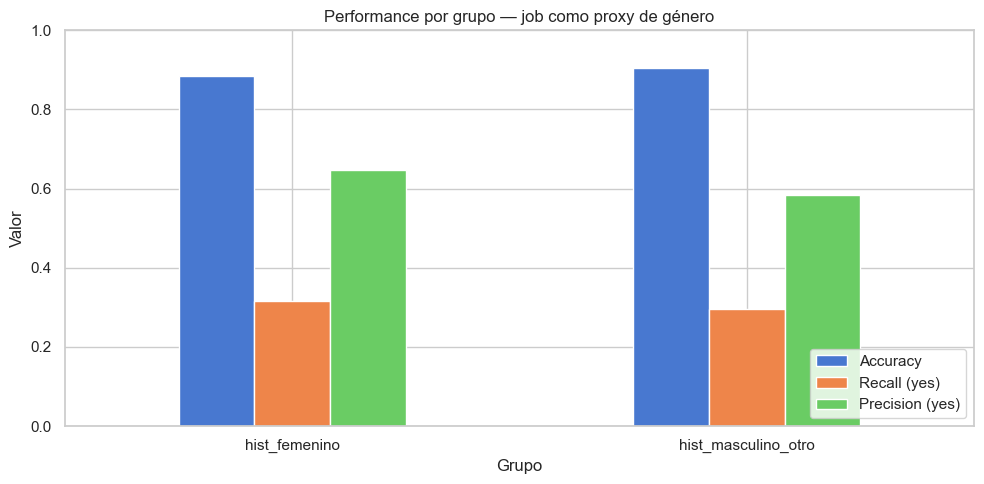

In [5]:
# Construir DataFrame de análisis con valores originales
test_idx = X_test.index
df_analysis = pd.DataFrame({
    'job': df_original.loc[test_idx, 'job'].values,
    'marital': df_original.loc[test_idx, 'marital'].values,
    'y_true': y_test.values,
    'y_pred': y_pred
})

# Crear proxy de género a partir de job
df_analysis['job_group'] = df_analysis['job'].apply(
    lambda x: 'hist_femenino' if x in ['housemaid', 'admin.'] else 'hist_masculino_otro'
)

print('Distribución de grupos (job como proxy de género):')
print(df_analysis['job_group'].value_counts())
print()

# Métricas por grupo
print('--- Performance por grupo (job) ---')
for grupo in ['hist_femenino', 'hist_masculino_otro']:
    mask = df_analysis['job_group'] == grupo
    yt = df_analysis.loc[mask, 'y_true']
    yp = df_analysis.loc[mask, 'y_pred']
    acc = accuracy_score(yt, yp)
    rec = recall_score(yt, yp, zero_division=0)
    pre = precision_score(yt, yp, zero_division=0)
    print(f'{grupo}: Accuracy={acc:.4f} | Recall(yes)={rec:.4f} | Precision(yes)={pre:.4f} | N={mask.sum()}')

# Visualización
metrics_job = []
for grupo in ['hist_femenino', 'hist_masculino_otro']:
    mask = df_analysis['job_group'] == grupo
    yt = df_analysis.loc[mask, 'y_true']
    yp = df_analysis.loc[mask, 'y_pred']
    metrics_job.append({
        'Grupo': grupo,
        'Accuracy': accuracy_score(yt, yp),
        'Recall (yes)': recall_score(yt, yp, zero_division=0),
        'Precision (yes)': precision_score(yt, yp, zero_division=0)
    })

df_metrics_job = pd.DataFrame(metrics_job).set_index('Grupo')

fig, ax = plt.subplots(figsize=(10, 5))
df_metrics_job.plot(kind='bar', ax=ax)
plt.title('Performance por grupo — job como proxy de género')
plt.ylabel('Valor')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Interpretación — job como proxy de género

Al desglosar la performance por el proxy de género (`job_group`), podemos observar si el modelo trata de forma diferente a los trabajos históricamente femeninos vs. los demás.

- Si el **Recall** de la clase 'yes' difiere significativamente entre grupos, significa que el modelo es mejor detectando potenciales suscriptores en un grupo que en otro.
- Dado que identificamos al **Falso Negativo como el error más costoso** (inciso b), una diferencia en Recall entre grupos indicaría que el banco está perdiendo más oportunidades de negocio con un grupo demográfico específico.

Esto es particularmente relevante desde la perspectiva de equidad: si el modelo sistemáticamente 'ignora' a potenciales suscriptoras en trabajos históricamente femeninos, estaría generando un sesgo de género indirecto.

---
# Análisis por variable protegida: `marital` como variable protegida oficial

El estado civil es una de las **variables protegidas oficiales** de este dataset (junto con la edad). Además, como vimos en el Ej1, el estado civil correlaciona fuertemente con la etapa de vida:
- **single** → tendencia a ser más joven
- **married** → mediana edad
- **divorced** → diversas edades, pero con sesgo hacia mayores

También identificamos en el Ej1 (sección D-iii) que `single` y `divorced` están sub-representados respecto a `married`, y que el modelo podría interpretar `single` como señal positiva.

Distribución de grupos (marital):
marital
married     5055
single      2296
divorced     871
Name: count, dtype: int64

--- Performance por grupo (marital) ---
married: Accuracy=0.9086 | Recall(yes)=0.2736 | Precision(yes)=0.5991 | N=5055
single: Accuracy=0.8724 | Recall(yes)=0.3483 | Precision(yes)=0.6042 | N=2296
divorced: Accuracy=0.9139 | Recall(yes)=0.2941 | Precision(yes)=0.6250 | N=871


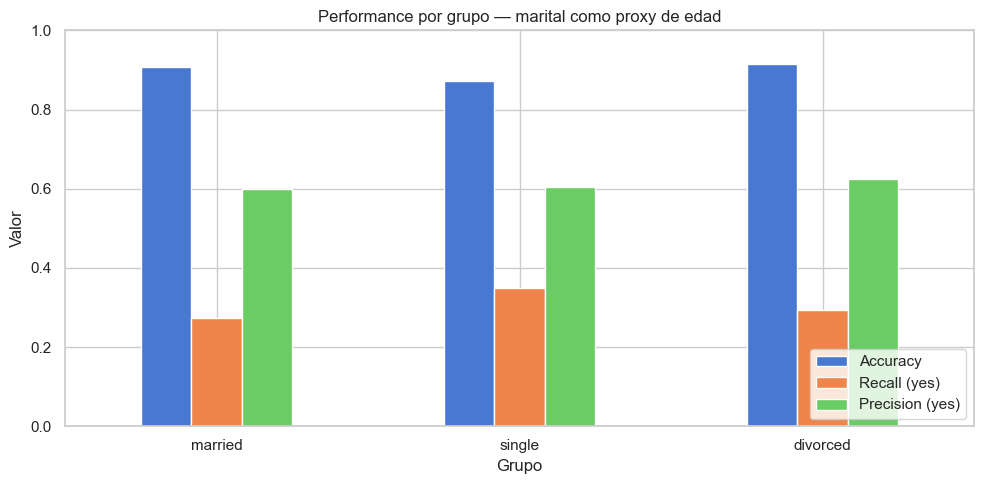

In [6]:
print('Distribución de grupos (marital):')
print(df_analysis['marital'].value_counts())
print()

# Métricas por grupo
print('--- Performance por grupo (marital) ---')
for grupo in ['married', 'single', 'divorced']:
    mask = df_analysis['marital'] == grupo
    yt = df_analysis.loc[mask, 'y_true']
    yp = df_analysis.loc[mask, 'y_pred']
    acc = accuracy_score(yt, yp)
    rec = recall_score(yt, yp, zero_division=0)
    pre = precision_score(yt, yp, zero_division=0)
    print(f'{grupo}: Accuracy={acc:.4f} | Recall(yes)={rec:.4f} | Precision(yes)={pre:.4f} | N={mask.sum()}')

# Visualización
metrics_mar = []
for grupo in ['married', 'single', 'divorced']:
    mask = df_analysis['marital'] == grupo
    yt = df_analysis.loc[mask, 'y_true']
    yp = df_analysis.loc[mask, 'y_pred']
    metrics_mar.append({
        'Grupo': grupo,
        'Accuracy': accuracy_score(yt, yp),
        'Recall (yes)': recall_score(yt, yp, zero_division=0),
        'Precision (yes)': precision_score(yt, yp, zero_division=0)
    })

df_metrics_mar = pd.DataFrame(metrics_mar).set_index('Grupo')

fig, ax = plt.subplots(figsize=(10, 5))
df_metrics_mar.plot(kind='bar', ax=ax)
plt.title('Performance por grupo — marital como variable protegida')
plt.ylabel('Valor')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Interpretación — marital como variable protegida

Al desglosar por estado civil observamos cómo el modelo trata a los tres grupos:

- Como notamos en el Ej1, el grupo `married` está sobrerrepresentado (~60% del dataset) mientras que `single` (~28%) y `divorced` (~11%) están subrepresentados.
- Si el Recall difiere entre grupos, el modelo estaría fallando más en detectar suscriptores potenciales de ciertos estados civiles/edades.
- Recordando que `single` se asocia con personas más jóvenes, y en el Ej1 notamos que los jóvenes y jubilados estaban subrepresentados, estas diferencias en performance podrían reflejar un sesgo etario.

En el **Ejercicio 3** formalizaremos este análisis usando los criterios de fairness vistos en clase.